# Import packages and libraries

In [19]:
import ase
import numpy as np
import matplotlib as plt
import os 
import sys 

print(f'ASE version : {ase.__version__}')
print(f'Numpy : {np.__version__}')
print(f'MatPlotLib : {plt.__version__}')

# Build Structure
from ase import atoms
from ase.build import bulk
from ase.build import make_supercell

# Nearest-Neigbour Analysis
from ase.data import atomic_masses, chemical_symbols
from ase.neighborlist import neighbor_list

# Visualise
from ase.visualize import view

#write and read file
from ase.io import read, write

# Auxilliary
from collections import Counter

# Directory
os.makedirs('structures/bulk_structures', exist_ok=True)

ASE version : 3.27.0
Numpy : 2.4.3
MatPlotLib : 3.10.8


# Build Structure

In [20]:
atom_name= 'Ni'
crystalstructure = 'fcc'
lattice_parameter = '3.571' #3.48 A from Material Project website
cubic = True
supercell_size= 5
bulk_xyz_path=f'{atom_name}_bulk.xyz'
supercell_xyz_path = f'{atom_name}_supercell.xyz'
alloy_name = 'Hastelloy_N'
unit_cell = bulk(name=atom_name, crystalstructure=crystalstructure, a=lattice_parameter, cubic=cubic)
bulk = unit_cell.repeat((5,5,5))
supercell = make_supercell(unit_cell, np.diag([supercell_size,supercell_size,supercell_size]))

In [21]:
# 1. Define the mapping
magmom_map_Ni = {'Ni': 0.71}

# 2. Generate the list based on the actual atoms in the 'bulk' object
# Default to 0.0 for any element not in your map
magmoms = [magmom_map_Ni.get(symbol, 0.0) for symbol in bulk.get_chemical_symbols()]

# 3. Apply to the atoms object
bulk.set_initial_magnetic_moments(magmoms)

# 4. Verification (Optional but helpful)
print(f"Initial magmoms: {bulk.get_initial_magnetic_moments()}")

Initial magmoms: [0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71
 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71 0.71

In [22]:
# # Check what you create
# print(f'Atomic Number : {bulk.get_atomic_numbers()}')
# print(f'Chemical Symbol : {bulk.get_chemical_symbols()}')

### Write out the pure metal file

In [24]:
# For .XYZ file
supercell_xyz_path = f'structures/bulk_structures/{atom_name}_supercell.xyz'
write(supercell_xyz_path, bulk, format="lammps-data", specorder=["Al", "B", "C", "Cr", "Fe", "Mo", "Ni", "H"])

# For .lammps file
MASSES = {
    1: (26.9815, 'Al'),
    2: (10.8110, 'B'),
    3: (12.0110, 'C'),
    4: (51.9961, 'Cr'),
    5: (55.8450, 'Fe'),
    6: (95.9600, 'Mo'),
    7: (58.6934, 'Ni'),
    8: ( 1.0080, 'H'),
}

elem_to_type = {el: t for t, (m, el) in MASSES.items()}

L    = supercell.cell.lengths()
pos  = supercell.get_positions()
syms = supercell.get_chemical_symbols()

lammps_path = f'structures/bulk_structures/{atom_name}_supercell.lammps'

with open(lammps_path, 'w') as f:
    f.write('# Pure Ni bulk — written by Notebook 01\n\n')
    f.write(f'{len(supercell)} atoms\n')
    f.write(f'{len(MASSES)} atom types\n\n')
    f.write(f'0.0  {L[0]:.10f}  xlo xhi\n')
    f.write(f'0.0  {L[1]:.10f}  ylo yhi\n')
    f.write(f'0.0  {L[2]:.10f}  zlo zhi\n\n')
    f.write('Masses\n\n')
    for t, (m, el) in MASSES.items():
        f.write(f'{t}  {m}  # {el}\n')
    f.write('\nAtoms # atomic\n\n')
    for i, (sym, p) in enumerate(zip(syms, pos), 1):
        t = elem_to_type[sym]
        f.write(f'{i}  {t}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')

print(f'Written : {lammps_path}')
print(f'Total atoms : {len(supercell)}')
print(f'All atoms type 8 (Ni) — all other types reserved for future use')

Written : structures/bulk_structures/Ni_supercell.lammps
Total atoms : 500
All atoms type 8 (Ni) — all other types reserved for future use


In [7]:
# # view before you proceed: ase.visualize import view: view(Ni,x3d)
# view(bulk, viewer='ngl')

In [8]:
# view(supercell, viewer='ngl')

In [9]:
# bulk.get_initial_magnetic_moments()

# Create several alloys from the above pure metal

Workflow
---------

> 1. Create a pure metal supercell
> 2. Rnadomly substitute other metal atoms into it to get the expected alloy type
> 3. Use different seeds to generate multiple alloy configurations of the same alloy
> 4. Set initial Magnetic moment of each atom present in the alloy
> 5. Write output
> 6. Post Processing Analysis
    a. Structure Summary
    b. Nearest-neighbour Distance Analysis
    c. LAMMPS Atom Type Mapping {This is very important for MACE and LAMMPS}

#### 1. Hastelloy Alloy Compositon

In [10]:
random_seed = [7, 42, 111, 1234, 12345]        
# Hastelloy N composition (atoms per 1500-atom cell)
# Based on nominal spec from Haynes International [4] and ORNL reports [1]
composition = {
    'Ni': 360,   # 72% — austenitic FCC matrix
    'Mo': 50,   # 10% — solid-solution strengthener, corrosion resistance
    'Cr': 42,   #  8.4% — oxidation / corrosion resistance
    'Fe': 18,   #  3.6% — residual from raw materials
    'Al': 10,   #  2% — deoxidiser, minor γ' former
    'C':  10,   #  2% — carbide former (M₆C, M₂₃C₆) [1,4]
    'B':  10,   #  2% — grain boundary strengthener, boride former [1,4]
}

# Verify sum
total    = sum(composition.values())
expected = 4 * supercell_size**3

if total != expected:
    raise ValueError(f'composition sums to {total}, must sum to {expected}.')

print(f'Supercell : {supercell_size}×{supercell_size}×{supercell_size}')
print(f'Atoms     : {total}  ({expected} expected) ✓')
print(f'a₀        : {lattice_parameter} Å  (Ref: Kittel 2005 [6])\n')
print(f'{"Element":>8s} {"Atoms":>6s} {"at%":>7s}')
print('-' * 24)
for elem, count in composition.items():
    print(f'{elem:>8s} {count:6d} {count/total*100:6.1f}%')
print('-' * 24)
print(f'{"Total":>8s} {total:6d} {100.0:6.1f}%')

Supercell : 5×5×5
Atoms     : 500  (500 expected) ✓
a₀        : 3.571 Å  (Ref: Kittel 2005 [6])

 Element  Atoms     at%
------------------------
      Ni    360   72.0%
      Mo     50   10.0%
      Cr     42    8.4%
      Fe     18    3.6%
      Al     10    2.0%
       C     10    2.0%
       B     10    2.0%
------------------------
   Total    500  100.0%


##### 2. Random Substitution

In [11]:
for seed in random_seed:
    np.random.seed(seed)  
    print(f'Random seed: {seed}  — document in lab notes')

    all_indices = np.arange(len(supercell))
    np.random.shuffle(all_indices)

    symbols = [atom_name] * len(supercell)

    pointer = 0
    substitution_log = []
    for element, count in composition.items():
        if element == atom_name:
            continue
        idx = all_indices[pointer:pointer + count]
        for i in idx:
            symbols[i] = element
        substitution_log.append((element, count, idx.tolist()))
        pointer += count

    supercell.set_chemical_symbols(symbols)

    # Verify
    actual = Counter(supercell.get_chemical_symbols())
    print(f'\n{"Element":>8s} {"Actual":>8s} {"Target":>8s} {"OK?":>5s}')
    print('-' * 35)
    ok = True
    for elem in composition:
        a, t = actual.get(elem, 0), composition[elem]
        match = '✓' if a == t else '✗'
        if a != t:
            ok = False
        print(f'{elem:>8s} {a:8d} {t:8d} {match:>5s}')
    print()
    print('✓ composition correct' if ok else '✗ MISMATCH — check composition dict')


    print(60 * '#')
    print("__starting magmon_mapping__")
    # Magnetic moments (μ_B) 
    magmom_map = {
        'Ni': 0.71,   # ferromagnetic bulk NiMaterial Project : https://next-gen.materialsproject.org/materials/mp-23?formula=Ni#crystal_structure
        'Mo': 0.0,    # Non- Magnetic
        'Cr': 0.0,    # Antimagnetic
        'Fe': 2.64,   # ferromagnetic 
        'Al': 0.0,    # Non- Magnetic
        'C':  0.0,    # Non- Magnetic
        'B':  0.0,    # Non- Magnetic
        'H':  0.0,    # Non- Magnetic
    }

    magmoms = [magmom_map.get(s, 0.0) for s in supercell.get_chemical_symbols()]
    supercell.set_initial_magnetic_moments(magmoms)


    actual = Counter(supercell.get_chemical_symbols())

    print(f'{"Element":>8s} {"μ_B":>8s} {"Count":>6s} {"Contrib (μ_B)":>14s}')
    print('-' * 40)
    total_mu = 0
    for elem, mu in magmom_map.items():
        n = actual.get(elem, 0)
        if n > 0:
            c = mu * n
            total_mu += c
            print(f'{elem:>8s} {mu:8.1f} {n:6d} {c:14.1f}')
    print('-' * 40)
    print(f'{"Total":>8s} {"":>8s} {len(supercell):6d} {total_mu:14.1f}')
    print('\n✓ Magnetic moments set')


    print(60 * '#')
    print('4a: Writing all .xyz file')
    print(60 * '#')

    alloy_xyz_path = f'structures/bulk_structures/{alloy_name}_{seed}_supercell.xyz'
    write(alloy_xyz_path, supercell)
    print(f'Written: {alloy_xyz_path}')


    print(60 * '#')
    print('4a: Writing all .lammps file')
    print(60 * '#')

    MASSES = {
    1: (26.9815, 'Al'),
    2: (10.8110, 'B'),
    3: (12.0110, 'C'),
    4: (51.9961, 'Cr'),
    5: (55.8450, 'Fe'),
    6: (95.9600, 'Mo'),
    7: (58.6934, 'Ni'),
    8: ( 1.0080, 'H'),   # no H atoms yet — required for Notebooks 05–11
    }

    alloy_lammps_path   = f'structures/bulk_structures/{alloy_name}_{seed}_supercell.lammps'
    L             = supercell.cell.lengths()
    pos           = supercell.get_positions()
    syms          = supercell.get_chemical_symbols()
    present_elems = sorted(set(syms))
    elem_to_type  = {el: i+1 for i, el in enumerate(present_elems)}

    with open(alloy_lammps_path, 'w') as f:
        # Header
        f.write('# Hastelloy N bulk — written \n\n')
        f.write(f'{len(supercell)} atoms\n')
        f.write(f'{len(MASSES)} atom types\n\n')
        # Box
        f.write(f'0.0  {L[0]:.10f}  xlo xhi\n')
        f.write(f'0.0  {L[1]:.10f}  ylo yhi\n')
        f.write(f'0.0  {L[2]:.10f}  zlo zhi\n\n')
        # Masses — before Atoms, all 8 types including H [15,16]
        f.write('Masses\n\n')
        for t, (m, el) in MASSES.items():
            f.write(f'{t}  {m}  # {el}\n')
        # Atoms
        f.write('\nAtoms # atomic\n\n')
        for i, (sym, p) in enumerate(zip(syms, pos), 1):
            t = elem_to_type[sym]
            f.write(f'{i}  {t}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')

    print(f'Written : {alloy_lammps_path}  → LAMMPS: read_data {alloy_lammps_path}')

    # Quick verification — print type mapping
    print(f'\nAtom type mapping (must match pair_coeff order in Notebook 02):')
    for t, (m, el) in MASSES.items():
        count = syms.count(el) if el in syms else 0
        note  = '← no atoms yet' if count == 0 else ''
        print(f'  Type {t}: {el:2s}  mass={m:.4f}  count={count}  {note}')

    # Provenance record [22]
    record_path = f'structures/bulk_structures/{alloy_name}_{seed}_generation_record.txt'
    with open(record_path, 'w') as f:
        f.write('Hastelloy N Bulk — Generation Record\n')
        f.write('=' * 45 + '\n')
        f.write(f'Notebook       : 01_bulk_structure_generation.ipynb\n')
        f.write(f'Random seed    : {seed}  \n')
        f.write(f'a0             : {lattice_parameter} Angstrom  (Ref: Kittel 2005 [6])\n')
        f.write(f'Supercell      : {supercell_size}x{supercell_size}x{supercell_size}\n')
        f.write(f'Total atoms    : {len(supercell)}\n')
        f.write(f'Box (Ang)      : {L[0]:.6f} x {L[1]:.6f} x {L[2]:.6f}\n')
        f.write(f'Atom types     : {len(MASSES)} (Al B C Cr Fe Mo Ni H)\n')
        f.write('\nComposition:\n')
        for elem, n in actual.items():
            f.write(f'  {elem}: {n} ({n/len(supercell)*100:.1f}%)\n')
        f.write('\nSubstituted indices (0-indexed):\n')
        for elem, count, idx in substitution_log:
            f.write(f'  {elem} ({count}): {idx}\n')

    print(f'Written : {record_path}  → provenance documentation [22]')
    print('\n✓ All files written successfully')

Random seed: 7  — document in lab notes

 Element   Actual   Target   OK?
-----------------------------------
      Ni      360      360     ✓
      Mo       50       50     ✓
      Cr       42       42     ✓
      Fe       18       18     ✓
      Al       10       10     ✓
       C       10       10     ✓
       B       10       10     ✓

✓ composition correct
############################################################
__starting magmon_mapping__
 Element      μ_B  Count  Contrib (μ_B)
----------------------------------------
      Ni      0.7    360          255.6
      Mo      0.0     50            0.0
      Cr      0.0     42            0.0
      Fe      2.6     18           47.5
      Al      0.0     10            0.0
       C      0.0     10            0.0
       B      0.0     10            0.0
----------------------------------------
   Total             500          303.1

✓ Magnetic moments set
############################################################
4a: Writing all .xyz

#### 3. Set initial Magnetic Moments

In [12]:
# # Magnetic moments (μ_B) 
# magmom_map = {
#     'Ni': 0.71,   # ferromagnetic bulk NiMaterial Project : https://next-gen.materialsproject.org/materials/mp-23?formula=Ni#crystal_structure
#     'Mo': 0.0,    # Non- Magnetic
#     'Cr': 0.0,    # Antimagnetic
#     'Fe': 2.64,   # ferromagnetic 
#     'Al': 0.0,    # Non- Magnetic
#     'C':  0.0,    # Non- Magnetic
#     'B':  0.0,    # Non- Magnetic
#     'H':  0.0,    # Non- Magnetic
# }

# magmoms = [magmom_map.get(s, 0.0) for s in supercell.get_chemical_symbols()]
# supercell.set_initial_magnetic_moments(magmoms)


# actual = Counter(supercell.get_chemical_symbols())

# print(f'{"Element":>8s} {"μ_B":>8s} {"Count":>6s} {"Contrib (μ_B)":>14s}')
# print('-' * 40)
# total_mu = 0
# for elem, mu in magmom_map.items():
#     n = actual.get(elem, 0)
#     if n > 0:
#         c = mu * n
#         total_mu += c
#         print(f'{elem:>8s} {mu:8.1f} {n:6d} {c:14.1f}')
# print('-' * 40)
# print(f'{"Total":>8s} {"":>8s} {len(supercell):6d} {total_mu:14.1f}')
# print('\n✓ Magnetic moments set')

# Write Output

##### Write xyz files

In [13]:
# for seed in random_seed:
#     alloy_xyz_path = 'structures/bulk_structures/{alloy_name}_{seed}_supercell.xyz'
#     write(alloy_xyz_path, supercell)
#     print('Written : {alloy_xyz_path}')

#### Structure Summary

In [14]:
from ase.io import read
os.makedirs('structures/bulk_structures/post_processing',exist_ok=True)
summary_path = f'structures/bulk_structures/post_processing/{alloy_name}_structure_summary.txt'

with open(summary_path, 'w') as f:
    for seed in random_seed:
        alloy_xyz_path = f'structures/bulk_structures/{alloy_name}_{seed}_supercell.xyz'
        struct = read(alloy_xyz_path)

        L = struct.cell.lengths()
        A = struct.cell.angles()
        P = struct.get_positions()
        S = Counter(struct.get_chemical_symbols())

        print('=' * 52, file=f)
        print(f'  STRUCTURE SUMMARY — seed {seed}', file=f)
        print('=' * 52, file=f)
        print(f'  Total atoms     : {len(struct)}', file=f)
        print(f'  a (Å)           : {L[0]:.6f}', file=f)
        print(f'  b (Å)           : {L[1]:.6f}', file=f)
        print(f'  c (Å)           : {L[2]:.6f}', file=f)
        print(f'  Angles (°)      : α={A[0]:.1f} β={A[1]:.1f} γ={A[2]:.1f}', file=f)
        print(f'  Volume (Å³)     : {struct.get_volume():.3f}', file=f)
        print(f'  Vol/atom (Å³)   : {struct.get_volume()/len(struct):.4f}', file=f)
        print(f'  PBC             : {struct.get_pbc()}', file=f)
        print(file=f)
        print('  Composition:', file=f)
        for elem in ['Ni', 'Mo', 'Cr', 'Fe', 'Al', 'C', 'B']:
            n = S.get(elem, 0)
            if n > 0:
                print(f'    {elem:4s}: {n:4d}  ({n/len(struct)*100:.1f}%)', file=f)
        print(file=f)
        print('  Position range:', file=f)
        for ax, label in enumerate(['x', 'y', 'z']):
            print(f'    {label}: {P[:,ax].min():.4f} → {P[:,ax].max():.4f} Å', file=f)
        print(file=f)

print(f'Written: {summary_path}')

Written: structures/bulk_structures/post_processing/Hastelloy_N_structure_summary.txt


### Nearest Neighbour Distance Analysis

In [15]:
from ase.io import read
from ase.neighborlist import neighbor_list

nn_summary_path = f'structures/bulk_structures/post_processing/{alloy_name}_nn_check.txt'

with open(nn_summary_path, 'w') as f:
    for seed in random_seed:
        alloy_xyz_path = f'structures/bulk_structures/{alloy_name}_{seed}_supercell.xyz'
        struct = read(alloy_xyz_path)

        a0 = float(lattice_parameter)
        i_idx, j_idx, dist, Distance_vector, Shift_vector = neighbor_list('ijdDS', struct, cutoff=3.5)

        min_dist    = dist.min()
        expected_nn = a0 / np.sqrt(2)   # FCC NN distance

        print('=' * 52, file=f)
        print(f'  NN CHECK — seed {seed}', file=f)
        print('=' * 52, file=f)
        print(f'  Nearest-neighbour check (FCC: a₀/√2 ≈ {expected_nn:.4f} Å):', file=f)
        print(f'  Expected NN distance : {expected_nn:.4f} Å', file=f)
        print(f'  Minimum found        : {min_dist:.4f} Å', file=f)
        print(f'  Deviation            : {abs(min_dist - expected_nn):.4f} Å', file=f)
        print(file=f)

        if min_dist < 2.0:
            print('✗  CRITICAL: atoms closer than 2.0 Å — overlapping atoms. Do NOT proceed.', file=f)
        elif min_dist < 2.2:
            print('⚠  WARNING: unusually short distance (<2.2 Å). Check adjacent large atoms (Mo).', file=f)
        else:
            print(f'✓  Min distance {min_dist:.4f} Å is physically reasonable', file=f)
            print(f'   (Slight deviation from ideal expected due to differing atomic radii)', file=f)

        # First-shell coordination (expect 12 for FCC)
        first_shell_cut = expected_nn * 1.15
        i_first = neighbor_list('i', struct, cutoff=first_shell_cut)
        nn_first = np.bincount(i_first, minlength=len(struct))
        unique_nn, counts_nn = np.unique(nn_first, return_counts=True)
        print(f'\n  First-shell coordination (cutoff {first_shell_cut:.3f} Å):', file=f)
        for nn, cnt in zip(unique_nn, counts_nn):
            note = ' ← expected FCC' if nn == 12 else ''
            print(f'    {nn:2d} neighbours : {cnt:4d} atoms{note}', file=f)
        print(file=f)

print(f'Written: {nn_summary_path}')

Written: structures/bulk_structures/post_processing/Hastelloy_N_nn_check.txt


#### LAMMPS Atom Type Mapping

In [16]:
os.makedirs('structures/bulk_structures/post_processing', exist_ok=True)
lammps_atom_type_mapping = f'structures/bulk_structures/post_processing/{alloy_name}_lammps_atom_type_mapping.txt'

with open(lammps_atom_type_mapping, 'w') as f:
    for seed in random_seed:
        alloy_xyz_path = f'structures/bulk_structures/{alloy_name}_{seed}_supercell.xyz'
        struct = read(alloy_xyz_path)

        present = sorted(set(struct.get_chemical_symbols()))   # ← struct not supercell
        actual  = Counter(struct.get_chemical_symbols())        # ← define locally

        print(f'seed {seed}', file=f)
        print('LAMMPS atom type mapping (alphabetical — ASE default):', file=f)
        print(f'{"Type":>6s}  {"Element":>8s}  {"Mass (g/mol)":>12s}  {"Count":>6s}', file=f)
        print('-' * 38, file=f)
        for i, elem in enumerate(present, 1):
            mass  = atomic_masses[chemical_symbols.index(elem)]
            count = actual.get(elem, 0)
            print(f'{i:6d}  {elem:>8s}  {mass:12.4f}  {count:6d}', file=f)

        next_type = len(present) + 1
        h_mass = atomic_masses[chemical_symbols.index('H')]
        print(f'{next_type:6d}  {"H":>8s}  {h_mass:12.4f}  {"(future)":>6s}  ← Notebooks 05–11', file=f)

        print(file=f)
        print('─' * 65, file=f)
        elem_str = ' '.join(present) + ' H'
        print('Required pair_coeff line in ALL LAMMPS scripts:', file=f)
        print(f'  pair_coeff * * /path/to/mace_model.model {elem_str}', file=f)
        print('─' * 65, file=f)
        print('⚠  The element order in pair_coeff must exactly match the type', file=f)
        print('   numbering in the LAMMPS data file. Verify every new script.', file=f)
        print(file=f)

print(f'Written: {lammps_atom_type_mapping}')  # ← outside with block, no file=f

Written: structures/bulk_structures/post_processing/Hastelloy_N_lammps_atom_type_mapping.txt


![Radial Distribution Function(RDF)](</projects/westgroup/akinyemi.az/mace_lammps/MHI_Nickel/structures/bulk_structures/Screenshot 2026-04-17 at 6.06.50 PM.png>)

In [17]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt

def compute_rdf(atoms, r_max=8.0, n_bins=200):
    dr     = r_max / n_bins
    r_vals = np.linspace(dr, r_max, n_bins)
    counts = np.zeros(n_bins)

    pos = atoms.get_positions()
    cell = atoms.get_cell()
    N   = len(atoms)
    V   = atoms.get_volume()

    for i in range(N):
        for j in range(i+1, N):
            diff = pos[j] - pos[i]
            # minimum image convention
            diff -= np.round(diff @ np.linalg.inv(cell)) @ cell
            r = np.linalg.norm(diff)
            if r < r_max:
                idx = int(r / dr)
                counts[idx] += 2   # count both i→j and j→i

    # Normalize
    rho = N / V
    g_r = counts / (N * 4 * np.pi * r_vals**2 * dr * rho)
    return r_vals, g_r

XYZError: ase.io.extxyz: Expected xyz header but got: invalid literal for int() with base 10: '(written by ASE)\n'

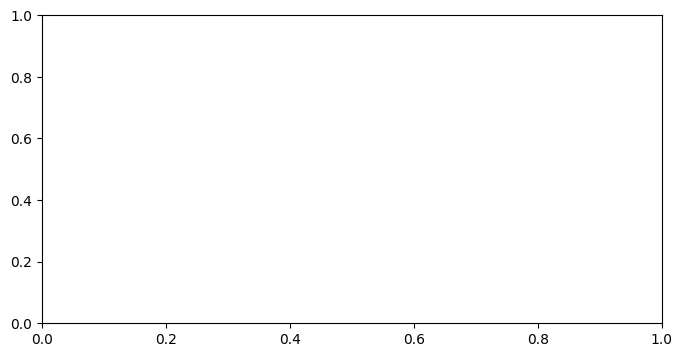

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

# Pure Ni reference
metal_xyz_path = f'structures/bulk_structures/{atom_name}_supercell.xyz'
metal_atoms = read(metal_xyz_path)
r_vals_1, g_r_1 = compute_rdf(metal_atoms)
ax.plot(r_vals_1, g_r_1, label='Pure Ni', color='black', lw=2, alpha=0.9)  # ← fixed

# Hastelloy N — 5 seeds
for seed in random_seed:
    alloy_xyz_path = f'structures/bulk_structures/{alloy_name}_{seed}_supercell.xyz'
    atoms = read(alloy_xyz_path)
    r_vals, g_r = compute_rdf(atoms)
    ax.plot(r_vals, g_r, label=f'seed {seed}', alpha=0.7)

ax.axvline(float(lattice_parameter)/np.sqrt(2), color='k',
           linestyle='--', label=f'a₀/√2 = {float(lattice_parameter)/np.sqrt(2):.3f} Å')
ax.set_xlabel('r (Å)')
ax.set_ylabel('g(r)')
ax.set_title('RDF — Pure Ni vs Hastelloy N bulk (5 seeds)')  # ← updated title
ax.legend()
plt.tight_layout()
plt.savefig('structures/bulk_structures/Ni_vs_HasteloyN_rdf.png', dpi=150)  # ← updated filename
plt.show()